# Logistic Regression for Shopping Preference Prediction

In this notebook we explore **Logistic Regression**, one of the most fundamental
machine learning algorithms for classification problems.

Our goal is to predict a customer's **shopping preference**:

- Online
- Store
- Hybrid

using behavioral, digital, and purchasing features.

This notebook demonstrates:

1. Mathematical intuition of Logistic Regression
2. Bias vs Variance behavior
3. When to use Logistic Regression
4. When not to use Logistic Regression
5. Hyperparameter tuning
6. Implementation using Scikit-Learn
7. Model interpretation

The notebook uses the **modular ML pipeline** implemented in the project:

- `src/data_loader.py`
- `src/features.py`
- `src/preprocess.py`

In [60]:
# Setup
import sys
sys.path.append("..")

# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from sklearn.model_selection import GridSearchCV

# Project modules
from src.data_loader import load_raw_data
from src.preprocess import preprocess_dataset

# Plot style
sns.set(style="whitegrid")

## Loading the Dataset

We load the raw dataset using our **data loader utility**.

The dataset contains customer behavioral and psychological features
related to online and store shopping.

In [61]:
dataset_name = "online vs store shopping dataset.csv"

df = load_raw_data(dataset_name)

df.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


## Preprocessing Pipeline

Our preprocessing pipeline performs:

1. Feature engineering
2. Train/test split
3. Feature scaling
4. Categorical encoding

This logic is centralized in `src/preprocess.py`.

In [62]:
X_train, X_test, y_train, y_test, preprocessor = preprocess_dataset(
    df,
    target_column="shopping_preference"
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (9431, 34)
Test shape: (2358, 34)


# Logistic Regression — Mathematical Intuition

Logistic Regression is a **linear model for classification**.

Instead of predicting a continuous value, it predicts a **probability**.

The model first computes a **linear combination of features**:

z = w1x1 + w2x2 + ... + b

Then it applies the **sigmoid function**:

σ(z) = 1 / (1 + e^-z)

This converts the output into a **probability between 0 and 1**.

For multi-class classification (our case):

Scikit-Learn uses **Softmax Regression**.

Softmax converts scores into class probabilities:

P(class_i) = exp(z_i) / Σ exp(z_j)

The predicted class is the one with the **highest probability**.

# Bias vs Variance Tradeoff

Logistic Regression is typically a **high bias, low variance** model.

Advantages:

- Stable
- Simple
- Hard to overfit
- Works well with small datasets

Disadvantages:

- Cannot capture complex nonlinear relationships
- Performance limited for complex problems

This makes Logistic Regression a **great baseline model**.

# When to Use Logistic Regression

Logistic Regression works best when:

✔ Relationship between features and target is **approximately linear**

✔ Dataset size is **small or medium**

✔ Interpretability is important

✔ Features are mostly **independent**

✔ You want a **fast baseline model**

Typical use cases:

- Customer churn prediction
- Credit risk scoring
- Medical diagnosis
- Marketing response prediction

# When NOT to Use Logistic Regression

Avoid Logistic Regression when:

❌ Data has **complex nonlinear relationships**

❌ Large number of feature interactions

❌ Image or text data

❌ Very high dimensional datasets

In such cases better models include:

- Random Forest
- Gradient Boosting
- Neural Networks
- SVM

# Training the Logistic Regression Model

In [63]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [64]:
predictions = log_reg.predict(X_test)

# Model Evaluation

In [65]:
print("Accuracy:", accuracy_score(y_test, predictions))
print("F1 Score:", f1_score(y_test, predictions, average="weighted"))

print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

Accuracy: 0.9580152671755725
F1 Score: 0.9659516134256111

Classification Report:

              precision    recall  f1-score   support

      Hybrid       0.43      1.00      0.60        74
      Online       1.00      0.94      0.97       235
       Store       1.00      0.96      0.98      2049

    accuracy                           0.96      2358
   macro avg       0.81      0.97      0.85      2358
weighted avg       0.98      0.96      0.97      2358



## Confusion Matrix

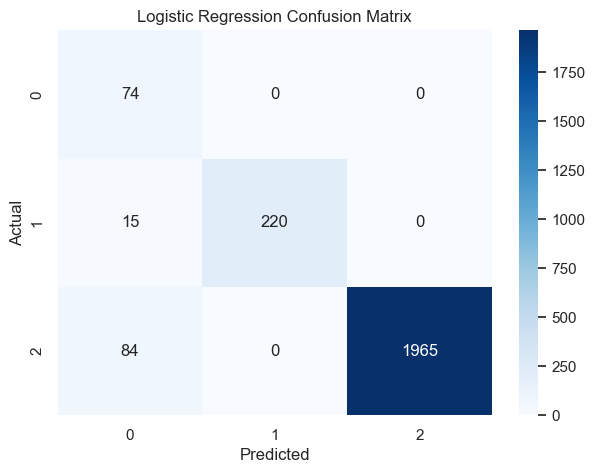

In [66]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.show()

# Hyperparameter Tuning

Important Logistic Regression hyperparameters:

| Parameter | Meaning |
|----------|--------|
| C | Regularization strength |
| penalty | L1 or L2 regularization |
| solver | Optimization algorithm |

Regularization prevents **overfitting**.

In [67]:
param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs"
    ),
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 10}


In [68]:
best_model = grid.best_estimator_

predictions = best_model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

      Hybrid       0.58      1.00      0.74        74
      Online       1.00      0.96      0.98       235
       Store       1.00      0.98      0.99      2049

    accuracy                           0.98      2358
   macro avg       0.86      0.98      0.90      2358
weighted avg       0.99      0.98      0.98      2358



# Interpreting Logistic Regression

One of the biggest advantages of Logistic Regression is **interpretability**.

Each feature has a **coefficient**.

Positive coefficient → increases probability of class  
Negative coefficient → decreases probability

In [69]:
coefficients = pd.DataFrame(
    best_model.coef_.T,
    columns=best_model.classes_
)

coefficients.head(10)

,Hybrid,Online,Store
0,-0.058536,0.046044,0.012492
1,-0.045065,0.126624,-0.081559
2,-0.114083,1.580660,-1.466577
3,-0.178514,0.090096,0.088418
4,0.110711,-1.158246,1.047535
5,-0.606763,3.750579,-3.143816
6,-0.611012,4.020843,-3.409831
7,-0.965943,5.493184,-4.527241
8,0.824738,-4.741894,3.917156
9,-0.011187,-0.600737,0.611924


# Key Insights

Logistic Regression provided a strong baseline model for predicting
customer shopping preferences.

Important observations:

- Digital engagement features strongly influence online shopping.
- Offline preference features drive store shopping.
- Behavioral ratios such as online order ratio improve prediction power.

Even though Logistic Regression is simple, it can perform
surprisingly well when features are well engineered.

# Next Steps

Next models to explore:

- Decision Trees
- Random Forest
- Gradient Boosting
- Support Vector Machines
- K Nearest Neighbors

These models will help capture **nonlinear patterns**
that Logistic Regression cannot model.